# Experiment-1

**Implementation of simple linear regression**

In [1]:
# Import all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [14]:
# Loading the dataset
df=pd.read_csv(r"C:\Users\Yug\Downloads\Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
# Extracting X(YearsExperience) and Y(Salary)
x=df.iloc[:,0].values
y=df.iloc[:,1].values

In [4]:
# Splitting the dataset (80-20)
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=1)

In [5]:
# Reshape the variables
x_train=x_train.reshape(-1,1)
x_test=x_test.reshape(-1,1)
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)

In [6]:
# Fitting linear model into training set
rc=LinearRegression()
rc.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Predict test set results
y_pred=rc.predict(x_test)
y_pred

array([[75074.50510972],
       [91873.8056381 ],
       [62008.38247653],
       [81607.56642631],
       [67608.14931932],
       [89073.92221671]])

In [8]:
# Compare with actual Y results
y_test

array([[83088.],
       [98273.],
       [63218.],
       [93940.],
       [61111.],
       [91738.]])

Text(0, 0.5, 'Salary')

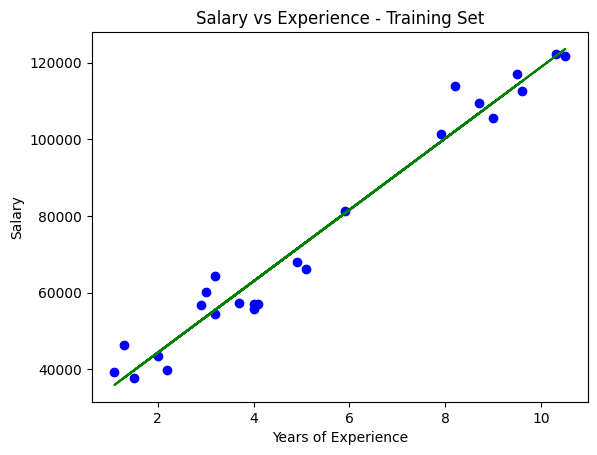

In [9]:
# Visualise the results -> training set
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, rc.predict(x_train), color='green')
plt.title("Salary vs Experience - Training Set")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

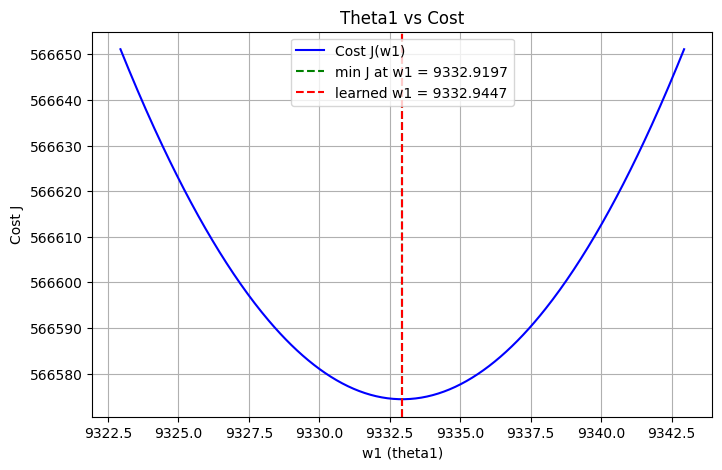

In [10]:
X = x_train.flatten()
Y = y_train.flatten()
m = X.size

learned_w0 = rc.intercept_[0]
learned_w1 = rc.coef_[0][0]

# Sweep around learned_w1 (adjust +/- if needed)
w1_vals = np.linspace(learned_w1 - 10, learned_w1 + 10, 400)
J_w1 = (1 / (2 * m)) * np.mean((learned_w0 + w1_vals[:, None] * X[None, :] - Y[None, :]) ** 2, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(w1_vals, J_w1, '-b', label='Cost J(w1)')
min_idx = np.argmin(J_w1)
plt.axvline(w1_vals[min_idx], color='g', linestyle='--', label=f'min J at w1 = {w1_vals[min_idx]:.4f}')
plt.axvline(learned_w1, color='r', linestyle='--', label=f'learned w1 = {learned_w1:.4f}')
plt.xlabel('w1 (theta1)')
plt.ylabel('Cost J')
plt.title('Theta1 vs Cost')
plt.legend()
plt.grid(True)
plt.show()

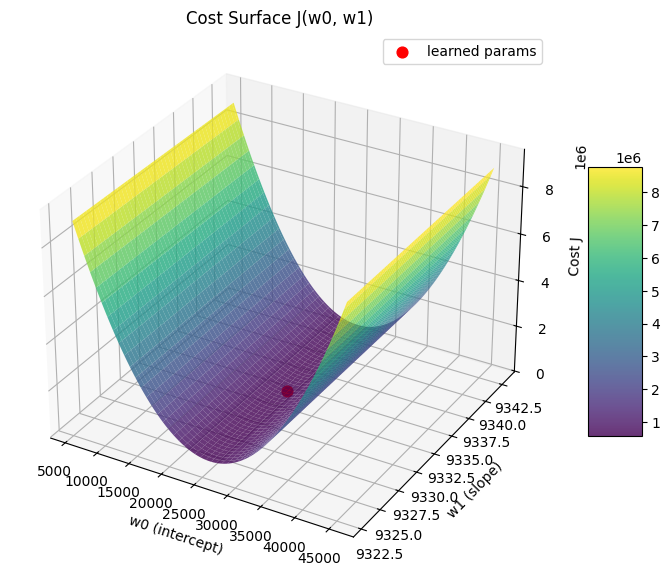

In [11]:
X = x_train.flatten()
Y = y_train.flatten()
m = X.size

# learned params
w0_hat = float(rc.intercept_.ravel()[0])
w1_hat = float(rc.coef_.ravel()[0])

# grid ranges (adjust if needed)
w0_vals = np.linspace(w0_hat - 20000, w0_hat + 20000, 100)
w1_vals = np.linspace(w1_hat - 10, w1_hat + 10, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)

# compute cost J over the grid
preds = W0[:, :, None] + W1[:, :, None] * X[None, None, :]
J = (1.0 / (2 * m)) * np.mean((preds - Y[None, None, :]) ** 2, axis=2)

# 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(W0, W1, J, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('w0 (intercept)')
ax.set_ylabel('w1 (slope)')
ax.set_zlabel('Cost J')
fig.colorbar(surf, shrink=0.5, aspect=5)

# mark learned params
learned_J = (1.0 / (2 * m)) * np.mean((w0_hat + w1_hat * X - Y) ** 2)
ax.scatter(w0_hat, w1_hat, learned_J, color='r', s=60, label='learned params')
ax.legend()
plt.title('Cost Surface J(w0, w1)')
plt.show()